In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from fastai.tabular.all import *
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## Load Model

In [2]:
learn = load_learner('models/model.pkl')
print("Model loaded successfully")

Model loaded successfully


## Single Student Prediction

In [3]:
student = {
    'age': 18,
    'gender': 'Male',
    'gaming_hours': 2.0,
    'study_hours': 1.0,
    'sleep_hours': 9.0,
    'attendance': 5.0,
    'gaming_genre': 'FPS',
    'social_activity': 3.0,
    'device_usage': 11.0,
    'reaction_time_ms': 90.0,
    'addiction_score': 2.0,
    'stress_level': 'High'
}

df = pd.DataFrame([student])
dl = learn.dls.test_dl(df)
pred, _ = learn.get_preds(dl=dl)
grade = float(pred.flatten()[0])

print(f"Predicted Grade: {grade:.1f} / 100")
if grade >= 85:
    print("Rating: Excellent")
elif grade >= 70:
    print("Rating: Good")
elif grade >= 50:
    print("Rating: Average")
elif grade >= 35:
    print("Rating: Below Average")
else:
    print("Rating: Struggling")

Predicted Grade: 17.7 / 100
Rating: Struggling


## Multiple Student Profiles

             Profile  Predicted Grade
         Heavy Gamer              6.0
    Balanced Student             91.3
Moderate Gamer (RPG)             50.9
           Non-Gamer             97.3
      Addicted Gamer              1.5


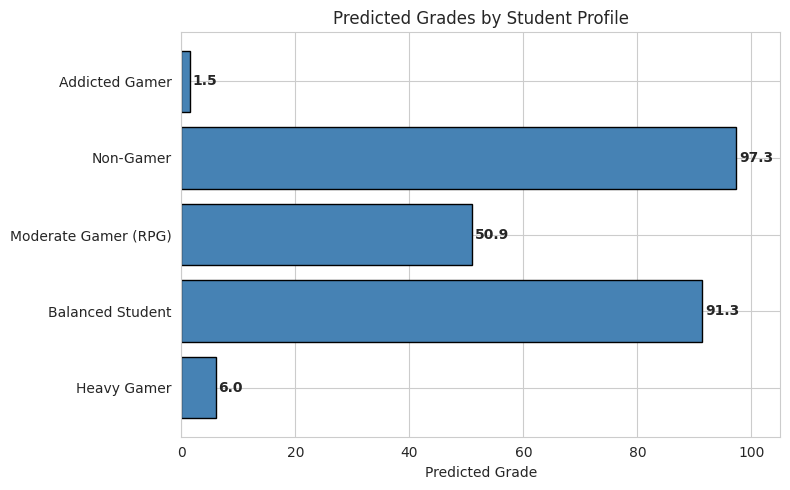

In [4]:
profiles = [
    {
        'name': 'Heavy Gamer',
        'data': {
            'age': 19, 'gender': 'Male', 'gaming_hours': 8.0, 'study_hours': 0.5,
            'sleep_hours': 5.0, 'attendance': 40.0, 'gaming_genre': 'FPS',
            'social_activity': 1.0, 'device_usage': 14.0, 'reaction_time_ms': 200.0,
            'addiction_score': 20.0, 'stress_level': 'High'
        }
    },
    {
        'name': 'Balanced Student',
        'data': {
            'age': 20, 'gender': 'Female', 'gaming_hours': 1.0, 'study_hours': 5.0,
            'sleep_hours': 7.5, 'attendance': 90.0, 'gaming_genre': 'Casual',
            'social_activity': 4.0, 'device_usage': 5.0, 'reaction_time_ms': 250.0,
            'addiction_score': 2.0, 'stress_level': 'Low'
        }
    },
    {
        'name': 'Moderate Gamer (RPG)',
        'data': {
            'age': 21, 'gender': 'Male', 'gaming_hours': 4.0, 'study_hours': 3.0,
            'sleep_hours': 6.5, 'attendance': 75.0, 'gaming_genre': 'RPG',
            'social_activity': 3.0, 'device_usage': 9.0, 'reaction_time_ms': 220.0,
            'addiction_score': 10.0, 'stress_level': 'Medium'
        }
    },
    {
        'name': 'Non-Gamer',
        'data': {
            'age': 18, 'gender': 'Female', 'gaming_hours': 0.0, 'study_hours': 6.0,
            'sleep_hours': 8.0, 'attendance': 95.0, 'gaming_genre': 'Casual',
            'social_activity': 5.0, 'device_usage': 3.0, 'reaction_time_ms': 300.0,
            'addiction_score': 0.0, 'stress_level': 'Low'
        }
    },
    {
        'name': 'Addicted Gamer',
        'data': {
            'age': 17, 'gender': 'Male', 'gaming_hours': 10.0, 'study_hours': 0.0,
            'sleep_hours': 4.0, 'attendance': 25.0, 'gaming_genre': 'FPS',
            'social_activity': 1.0, 'device_usage': 16.0, 'reaction_time_ms': 150.0,
            'addiction_score': 25.0, 'stress_level': 'High'
        }
    }
]

results = []
for p in profiles:
    df_p = pd.DataFrame([p['data']])
    dl_p = learn.dls.test_dl(df_p)
    pred_p, _ = learn.get_preds(dl=dl_p)
    grade_p = float(pred_p.flatten()[0])
    results.append({'Profile': p['name'], 'Predicted Grade': round(grade_p, 1)})

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(results_df['Profile'], results_df['Predicted Grade'], color='steelblue', edgecolor='black')
for bar, grade in zip(bars, results_df['Predicted Grade']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, f'{grade:.1f}', va='center', fontweight='bold')
ax.set_xlim(0, 105)
ax.set_xlabel('Predicted Grade')
ax.set_title('Predicted Grades by Student Profile')
plt.tight_layout()
plt.show()

## Batch Prediction from CSV

In [5]:
import os

csv_path = 'data/test.csv'
if not os.path.exists(csv_path):
    print(f"{csv_path} not found. Creating test set from full dataset...")
    full_df = pd.read_csv('./data/Gaming_Academic_Performance.csv')
    test_df = full_df.sample(frac=0.1, random_state=42)
    test_df.to_csv(csv_path, index=False)
    print(f"Created {csv_path} with {len(test_df)} rows")

df_csv = pd.read_csv(csv_path)
dl_csv = learn.dls.test_dl(df_csv)
preds_csv, _ = learn.get_preds(dl=dl_csv)
df_csv['predicted_grade'] = np.round(preds_csv.flatten(), 1)

col = [c for c in ['student_id', 'grades', 'predicted_grade'] if c in df_csv.columns]
print(df_csv[col].head(10).to_string(index=False))
print(f"\nTotal predictions: {len(df_csv)}")

data/test.csv not found. Creating test set from full dataset...
Created data/test.csv with 800 rows


 student_id     grades  predicted_grade
       2216  57.286971        47.400002
       2583  76.020000        74.599998
       1663  42.680000        51.599998
       3028  17.310000        18.100000
       4344 106.774359        90.000000
       2681  45.690000        51.000000
       1766  40.860000        47.299999
       1124  83.990000        89.300003
       4055  92.690000        94.800003
       3762 100.000000        99.400002

Total predictions: 800


## Test Set Analysis

In [6]:
if 'grades' in df_csv.columns:
    actual = df_csv['grades']
    predicted = df_csv['predicted_grade']

    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    r2 = r2_score(actual, predicted)

    print("=" * 40)
    print("TEST SET METRICS")
    print("=" * 40)
    print(f"MAE:  {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²:   {r2:.4f}")
    print("=" * 40)
else:
    print('No "grades" column in CSV. Cannot calculate metrics.')

TEST SET METRICS
MAE:  4.9141
RMSE: 6.2453
R²:   0.9205


In [7]:
if 'grades' in df_csv.columns:
    df_csv['error'] = abs(df_csv['grades'] - df_csv['predicted_grade'])

    print(f"Within 5 points:  {(df_csv['error'] <= 5).mean() * 100:.2f}%")
    print(f"Within 10 points: {(df_csv['error'] <= 10).mean() * 100:.2f}%")
    print(f"Within 15 points: {(df_csv['error'] <= 15).mean() * 100:.2f}%")
    print(f"Mean absolute error: {df_csv['error'].mean():.2f} points")
else:
    print('No "grades" column in CSV.')

Within 5 points:  56.88%
Within 10 points: 88.88%
Within 15 points: 98.38%
Mean absolute error: 4.91 points


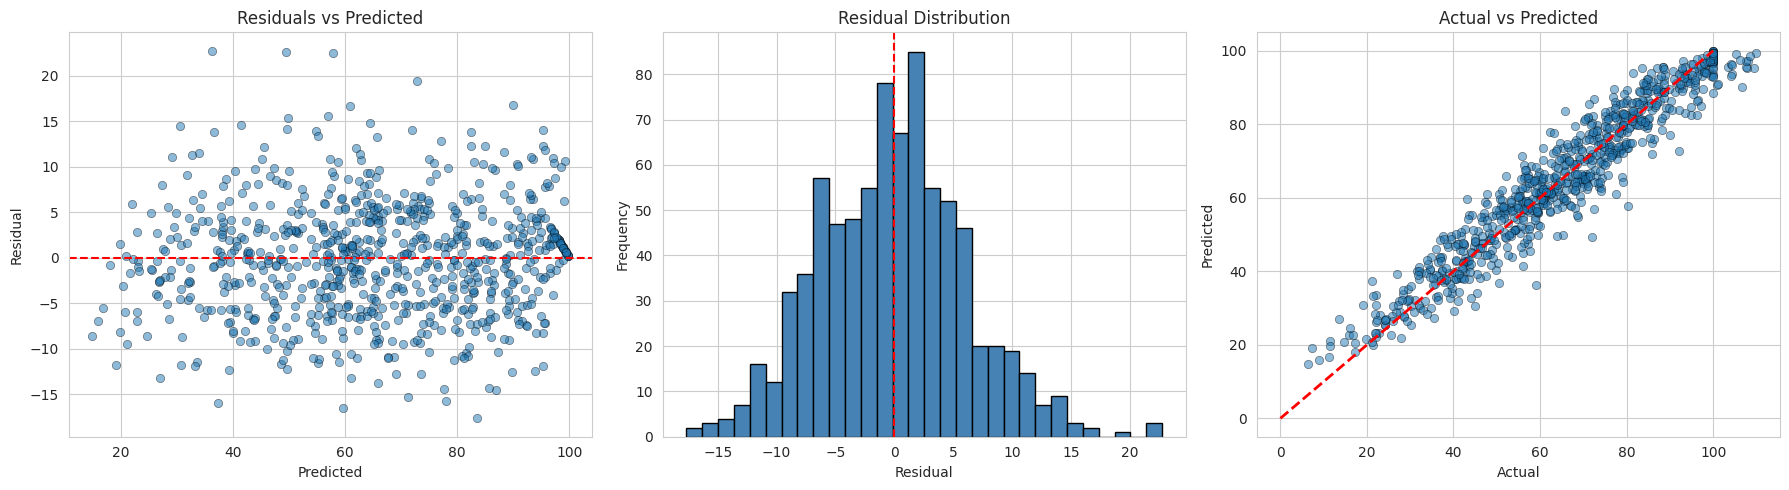

In [8]:
if 'grades' in df_csv.columns:
    actual = df_csv['grades'].values
    predicted = df_csv['predicted_grade'].values
    residuals = actual - predicted

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].scatter(predicted, residuals, alpha=0.5, edgecolors='k', linewidths=0.5)
    axes[0].axhline(y=0, color='r', linestyle='--')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Residual')
    axes[0].set_title('Residuals vs Predicted')

    axes[1].hist(residuals, bins=30, edgecolor='black', color='steelblue')
    axes[1].axvline(x=0, color='r', linestyle='--')
    axes[1].set_xlabel('Residual')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title('Residual Distribution')

    axes[2].scatter(actual, predicted, alpha=0.5, edgecolors='k', linewidths=0.5)
    axes[2].plot([0, 100], [0, 100], 'r--', linewidth=2)
    axes[2].set_xlabel('Actual')
    axes[2].set_ylabel('Predicted')
    axes[2].set_title('Actual vs Predicted')

    plt.tight_layout()
    plt.show()
else:
    print('No "grades" column in CSV.')

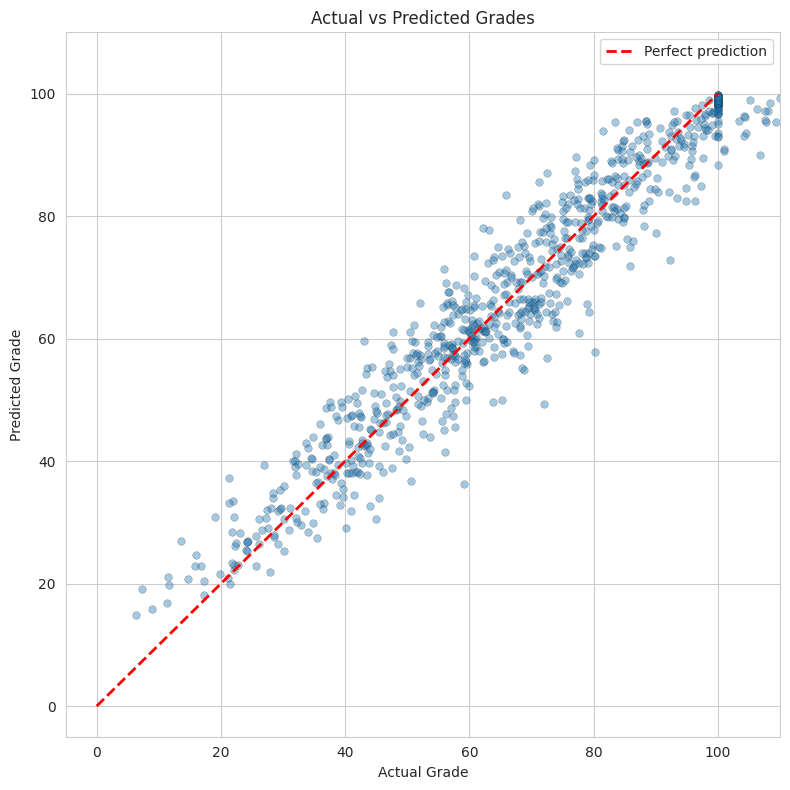

In [9]:
if 'grades' in df_csv.columns:
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.scatter(df_csv['grades'], df_csv['predicted_grade'], alpha=0.4, s=30, edgecolors='k', linewidths=0.3)
    ax.plot([0, 100], [0, 100], 'r--', linewidth=2, label='Perfect prediction')
    ax.set_xlabel('Actual Grade')
    ax.set_ylabel('Predicted Grade')
    ax.set_title('Actual vs Predicted Grades')
    ax.legend()
    ax.set_xlim(-5, 110)
    ax.set_ylim(-5, 110)
    plt.tight_layout()
    plt.show()